# Intro

**Seminar by @Elad_Benjo**

In this notebook I will attempt to develop a new model for nowcsating of the Israeli GDP.

Our efforts would be towards a DFM, since we have various frequencies and high demensional data.

In [1]:
from google.colab import drive
import sys
import pandas as pd

drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/gdp_nowcasting_seminar/src')

Mounted at /content/drive


## Papers

https://www.federalreserve.gov/econres/ifdp/files/ifdp1385.pdf

# Pre-model Prep

In [ ]:
import pandas as pd

In [ ]:
daily_df = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/feature_selected/daily_data.pkl')

In [12]:
monthly_df = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/feature_selected/monthly_data.pkl')

In [13]:
monthly_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 1995-01-01 to 2025-04-01
Freq: MS
Data columns (total 43 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Total refunds from the Income Tax Department                                    339 non-null    float64
 1   self employed returns                                                           339 non-null    float64
 2   Cancellations Deductions                                                        352 non-null    float64
 3   Capital Gas Tax Refunds                                                         351 non-null    float64
 4   Cancellation companies                                                          352 non-null    float64
 5   Purchase returns                                                                351 non-null    flo

In [14]:
monthly_df.head(15)

,Total refunds from the Income Tax Department,self employed returns,Cancellations Deductions,Capital Gas Tax Refunds,Cancellation companies,Purchase returns,Independent Cancellations,VAT refund autonomy and traders,"Unemployment rate (ages 25-64, percentage pots)",VAT_rate,...,Goods and services,Independents advances,Self-employed tax differences,Non-profit institution tax,tax differential companies,Companies advances,Income tax for self-employed dividuals and companies (advances and deductions),Deduction from salary,Deductions and the capital market,Total Income Tax Division Net
Date,,,,,,,,,,,,,,,,,,,,,
1995-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


0, 1, 2, 3, 4, 5, 6, 7, 10, 16, 19, 20, 21, 23, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42

In [4]:
monthly_df.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 10, 16, 19, 20, 21, 23, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]] = monthly_df.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 10, 16, 19, 20, 21, 23, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]].shift(1)

In [ ]:
import preprocessing

In [ ]:
df_X = preprocessing.merge_series_freq({'d': daily_df, 'm': monthly_df})

In [ ]:
df_X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9482 entries, 1995-01-01 to 2025-08-01
Data columns (total 47 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   d_TA125                                                                           4879 non-null   float64
 1   d_SP500                                                                           6135 non-null   float64
 2   d_USD_ILS                                                                         5969 non-null   float64
 3   d_SPGSCI                                                                          6135 non-null   float64
 4   m_Total refunds from the Income Tax Department                                    339 non-null    float64
 5   m_self employed returns                                                           339 non-nul

In [ ]:
df_X = df_X.asfreq("D")

In [ ]:
print(df_X.index.freq)

<Day>


In [ ]:
df_X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11171 entries, 1995-01-01 to 2025-08-01
Freq: D
Data columns (total 47 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   d_TA125                                                                           4879 non-null   float64
 1   d_SP500                                                                           6135 non-null   float64
 2   d_USD_ILS                                                                         5969 non-null   float64
 3   d_SPGSCI                                                                          6135 non-null   float64
 4   m_Total refunds from the Income Tax Department                                    339 non-null    float64
 5   m_self employed returns                                                           33

## Publication Shifts

### legacy

Tax information is relead in a 10 days delay

In [ ]:
df_X.iloc[:, [4, 5, 6, 7, 8, 9, 10, 11, 14, 20, 23, 24, 25, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]] = df_X.iloc[:, [4, 5, 6, 7, 8, 9, 10, 11, 14, 20, 23, 24, 25, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]].shift(10)

CPI is 15 days later  
Consumer Trust Index is 12 days later  
Unemployment rate is 16 days later  
Real Credit Card Usage is 3 days later


In [ ]:
df_X.iloc[:, [17]] = df_X.iloc[:, [17]].shift(15)
df_X.iloc[:, [19]] = df_X.iloc[:, [19]].shift(12)
df_X.iloc[:, [12]] = df_X.iloc[:, [12]].shift(16)
df_X.iloc[:, [21]] = df_X.iloc[:, [21]].shift(3)

real salary delay is 50 days then drop it

In [ ]:
df_X = df_X.drop(df_X.columns[26], axis=1)

drop the first 2 rows, and anything beyond 16.1.25

In [ ]:
df_X = df_X.iloc[2:]
df_X = df_X[:'2025-01-16']

### ragged edge

all of our data is delayed between 1-18 days from the end of the month

In [5]:
monthly_df = monthly_df.shift(1)

salaried jobs is delayed 50 days, then push it 1 more month forward.

In [6]:
monthly_df.iloc[:, [22]] = monthly_df.iloc[:, [22]].shift(1)

In [7]:
monthly_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 1995-01-01 to 2025-04-01
Freq: MS
Data columns (total 43 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Total refunds from the Income Tax Department                                    337 non-null    float64
 1   self employed returns                                                           337 non-null    float64
 2   Cancellations Deductions                                                        350 non-null    float64
 3   Capital Gas Tax Refunds                                                         349 non-null    float64
 4   Cancellation companies                                                          350 non-null    float64
 5   Purchase returns                                                                349 non-null    flo

## Train-Test Split

I split the data according to the model currently used by the Ministry of Finance, in order to maintain a relevant basis for performance comparison.

In [ ]:
df_X.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/df_X.pkl')

In [ ]:
x_train = df_X[:'2022-01-16']
x_test = df_X['2022-01-17':]

In [ ]:
x_train.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/x_train.pkl')

In [ ]:
x_test.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/x_test.pkl')

In [ ]:
df_Y = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/stationary/quarterly_data.pkl')

In [ ]:
df_Y.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 119 entries, 1995-06-30 to 2024-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GDP     119 non-null    float64
 1   C       119 non-null    float64
 2   G       115 non-null    float64
 3   I       119 non-null    float64
 4   EX      119 non-null    float64
 5   IM      119 non-null    float64
dtypes: float64(6)
memory usage: 6.5 KB


In [ ]:
df_Y.tail(20)

,GDP,C,G,I,EX,IM
Date,,,,,,
2020-03-31,-0.020815,-0.059381,-0.032948,0.005003,-0.030563,-0.066587
2020-06-30,-0.086301,-0.122846,0.013079,-0.140037,-0.085846,-0.114879
2020-09-30,0.085868,0.080171,0.025859,0.059847,0.102935,-0.008056
2020-12-31,0.025544,0.044362,0.024968,0.132744,0.026366,0.169621
2021-03-31,0.004977,0.004431,0.007891,-0.018693,0.040784,0.029436
2021-06-30,0.034456,0.063183,-0.001098,0.033092,0.024298,0.044995
2021-09-30,0.019257,0.013908,-0.026294,0.034772,0.038396,0.033290
2021-12-31,0.043839,0.034346,0.010034,0.039539,0.064620,0.065860
2022-03-31,-0.006193,0.010369,-0.014388,0.031372,-0.001565,0.033355


In [ ]:
y_train = df_Y[:'2021-12-31']
y_test = df_Y['2022-01-01':]

In [ ]:
y_train.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_train.pkl')

In [ ]:
y_test.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_test.pkl')

In [ ]:
x_train.tail()

,d_TA125,d_SP500,d_USD_ILS,d_SPGSCI,m_Total refunds from the Income Tax Department,m_self employed returns,m_Cancellations Deductions,m_Capital Gas Tax Refunds,m_Cancellation companies,m_Purchase returns,...,m_Goods and services,m_Independents advances,m_Self-employed tax differences,m_Non-profit institution tax,m_tax differential companies,m_Companies advances,m_Income tax for self-employed dividuals and companies (advances and deductions),m_Deduction from salary,m_Deductions and the capital market,m_Total Income Tax Division Net
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-12,0.015241,0.002814,-0.004608,0.012775,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-13,0.006246,-0.014346,0.001806,-0.009244,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-14,NaN,0.000820,-0.001726,0.011274,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
y_train.tail()

,GDP,C,G,I,EX,IM
Date,,,,,,
2020-12-31,0.025544,0.044362,0.024968,0.132744,0.026366,0.169621
2021-03-31,0.004977,0.004431,0.007891,-0.018693,0.040784,0.029436
2021-06-30,0.034456,0.063183,-0.001098,0.033092,0.024298,0.044995
2021-09-30,0.019257,0.013908,-0.026294,0.034772,0.038396,0.033290
2021-12-31,0.043839,0.034346,0.010034,0.039539,0.064620,0.065860


### ragged edge

In [ ]:
monthly_df.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/monthly_df_ragged_edge.pkl')

In [57]:
monthly_df = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/monthly_df_ragged_edge.pkl')

In [59]:
monthly_df_train = monthly_df[:'2022-01-16']
monthly_df_test = monthly_df['2021-06-01':]

In [ ]:
monthly_df_train.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/monthly_df_train.pkl')

In [60]:
monthly_df_test.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/monthly_df_test.pkl')

In [15]:
monthly_df_train = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/monthly_df_train.pkl')

In [18]:
monthly_df_train

,Total refunds from the Income Tax Department,self employed returns,Cancellations Deductions,Capital Gas Tax Refunds,Cancellation companies,Purchase returns,Independent Cancellations,VAT refund autonomy and traders,"Unemployment rate (ages 25-64, percentage pots)",VAT_rate,...,Goods and services,Independents advances,Self-employed tax differences,Non-profit institution tax,tax differential companies,Companies advances,Income tax for self-employed dividuals and companies (advances and deductions),Deduction from salary,Deductions and the capital market,Total Income Tax Division Net
Date,,,,,,,,,,,,,,,,,,,,,
1995-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-01,-252865.0,-32747.0,-16928.0,-12831.0,-24034.500966,-15068.0,11530.0,-569.0,0.000000,0.0,...,375302.0,0.047214,-0.280185,-110280.0,-0.088277,-0.036768,-0.071926,496637.0,614408.0,0.033164
2021-10-01,568385.0,161026.0,-20627.0,37775.0,3608.264582,24253.0,-4272.0,1654.0,0.000000,0.0,...,-423300.0,-0.347407,-0.573319,22311.0,-0.087606,-0.077336,-0.192220,-1075462.0,-1299212.0,-0.142108
2021-11-01,-521275.0,-252330.0,-18764.0,-13567.0,3806.030129,-2911.0,-36350.0,-2324.0,-0.087011,0.0,...,-113752.0,0.588327,0.666583,421514.0,-0.108037,0.123107,0.247500,501038.0,679313.0,0.161094


In [16]:
monthly_df_test = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/monthly_df_test.pkl')

In [61]:
monthly_df_test

,Total refunds from the Income Tax Department,self employed returns,Cancellations Deductions,Capital Gas Tax Refunds,Cancellation companies,Purchase returns,Independent Cancellations,VAT refund autonomy and traders,"Unemployment rate (ages 25-64, percentage pots)",VAT_rate,...,Goods and services,Independents advances,Self-employed tax differences,Non-profit institution tax,tax differential companies,Companies advances,Income tax for self-employed dividuals and companies (advances and deductions),Deduction from salary,Deductions and the capital market,Total Income Tax Division Net
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-01,-209160.0,50782.0,-17506.0,12792.0,3433.202392,3234.0,403.0,-176.0,-0.019803,0.000000,...,166335.0,-0.236616,-0.712830,-56269.0,0.102229,-0.015748,-0.112422,-370956.0,89619.0,-0.048960
2021-07-01,-185828.0,262601.0,-254927.0,-4587.0,-30093.032060,-47234.0,10852.0,-824.0,0.000000,0.000000,...,-138152.0,-0.358653,0.643132,131250.0,-0.536557,-0.077660,-0.072767,-397823.0,-707732.0,-0.042761
2021-08-01,355997.0,-245448.0,-39362.0,-7562.0,8213.733487,42525.0,-14220.0,477.0,-0.040822,0.000000,...,66593.0,0.424851,-0.260796,-36841.0,0.327729,0.046460,0.097231,286720.0,654980.0,0.038303
2021-09-01,-252865.0,-32747.0,-16928.0,-12831.0,-24034.500966,-15068.0,11530.0,-569.0,0.000000,0.000000,...,375302.0,0.047214,-0.280185,-110280.0,-0.088277,-0.036768,-0.071926,496637.0,614408.0,0.033164
2021-10-01,568385.0,161026.0,-20627.0,37775.0,3608.264582,24253.0,-4272.0,1654.0,0.000000,0.000000,...,-423300.0,-0.347407,-0.573319,22311.0,-0.087606,-0.077336,-0.192220,-1075462.0,-1299212.0,-0.142108
2021-11-01,-521275.0,-252330.0,-18764.0,-13567.0,3806.030129,-2911.0,-36350.0,-2324.0,-0.087011,0.000000,...,-113752.0,0.588327,0.666583,421514.0,-0.108037,0.123107,0.247500,501038.0,679313.0,0.161094
2021-12-01,74216.0,27974.0,-20177.0,-34568.0,10167.795677,-8297.0,-22417.0,736.0,-0.146603,0.000000,...,334914.0,-0.284385,0.200978,-331902.0,0.880566,-0.200884,-0.001377,219143.0,209760.0,-0.003421
2022-01-01,38681.0,40752.0,-19636.0,6987.0,10145.561224,-6309.0,61217.0,-1500.0,-0.054067,0.000000,...,-89128.0,-0.059806,-0.300434,143812.0,-0.626747,0.392857,0.072415,-78020.0,636338.0,0.055052
2022-02-01,-177584.0,6498.0,-76074.0,3775.0,-10616.673228,277.0,-7461.0,2209.0,-0.087011,0.000000,...,609199.0,0.423548,-0.295354,-221522.0,0.319927,-0.584544,-0.012187,395971.0,615595.0,-0.021346


## Remove empty rows

In [ ]:
import pandas as pd

In [ ]:
df_X_train = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/df_X_train.pkl')

In [ ]:
# מספר השורות הכולל
total_rows = len(x_train)

# כמה שורות הן לגמרי ריקות (כל העמודות NaN)
empty_rows = x_train.isna().all(axis=1).sum()

# אחוז שורות ריקות
empty_pct = empty_rows / total_rows * 100

print(f"Total rows: {total_rows}")
print(f"Completely empty rows: {empty_rows}")
print(f"Percentage empty: {empty_pct:.2f}%")


Total rows: 9876
Completely empty rows: 3219
Percentage empty: 32.59%


In [ ]:
# 1. remove rows that contain all NaN
df_x_train = df_X_train.dropna(how="all")

# 2. recreate continues daily index
full_index = pd.date_range(df_X_train.index.min(), df_X_train.index.max(), freq="D")
df_x_train = df_x_train.reindex(full_index)

print(df_X_train.shape, " -> ", df_x_train.shape)


(9860, 47)  ->  (9860, 47)


## Z-Score

In [20]:
import stats_trans

In [ ]:
mu, sigma = stats_trans.fit_zscore(x_train)

In [ ]:
x_train_z_score = stats_trans.transform_zscore(x_train, mu, sigma)

In [ ]:
x_train_z_score.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/df_x_train_z_score.pkl')

### ragged edge

In [21]:
mu, sigma = stats_trans.fit_zscore(monthly_df_train)

In [ ]:
monthly_df_train_z_score = stats_trans.transform_zscore(monthly_df_train, mu, sigma)

In [ ]:
monthly_df_train_z_score.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/monthly_df_train_z_score.pkl')

In [37]:
monthly_df_train_z_score = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/monthly_df_train_z_score.pkl')

In [62]:
monthly_df_test_z_score = stats_trans.transform_zscore(monthly_df_test, mu, sigma)

In [63]:
monthly_df_test_z_score.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/monthly_df_test_z_score.pkl')

# DFM

In [ ]:
import pandas as pd

In [ ]:
x_train_z_score = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/df_x_train_z_score.pkl')

In [ ]:
import dfm

In [ ]:
import importlib

In [ ]:
importlib.reload(dfm)

<module 'dfm' from '/content/drive/MyDrive/gdp_nowcasting_seminar/src/dfm.py'>

In [ ]:
max_factors = dfm.max_possible_factors(init_tester)
print(f"Max factors you can safely request: {max_factors}")


Max factors you can safely request: 46


## 1 factor

### pre-train

fill the NaN to initialize weights for the model

In [ ]:
x_train_init = dfm.make_init_filled(x_train_z_score)

In [ ]:
import statsmodels.api as sm

In [ ]:
k_factors = 1
factor_order = 1

mod_init = sm.tsa.DynamicFactor(
    x_train_init,
    k_factors=k_factors,
    factor_order=factor_order,
    error_cov_type="diagonal"
)

In [ ]:
init_powell = mod_init.fit(method="powell", maxiter=15, disp=True)

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3398: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 55.708953
         Iterations: 15
         Function evaluations: 14903


In [ ]:
import pickle

with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/init_powell_fit.pkl", "wb") as f:
    pickle.dump(init_powell, f)


In [ ]:
init_res = mod_init.fit(
    start_params=init_powell.params,
    method="lbfgs",
    maxiter=50,
    full_output=True,
    disp=True,
    optim_score='approx',
    optim_kwds={
        "pgtol": 1e-6,
        "maxfun": 5000
    }
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: optim_kwds. After release 0.14, this will raise.
  warnings.warn(


In [ ]:
with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/init_res_fit.pkl", "wb") as f:
    pickle.dump(init_res, f)


In [ ]:
print(f"Powell LLF: {init_powell.llf}")
print(f"LBFGS LLF:  {init_res.llf}")

Powell LLF: -550181.6237712372
LBFGS LLF:  -548316.9486236731


### original data

after weights were initialized we can adjust to the set with NaNs

In [ ]:
mod_final = sm.tsa.DynamicFactor(
    x_train_z_score,
    k_factors=k_factors,
    factor_order=factor_order,
    error_cov_type="diagonal"
)

In [ ]:
final_res = mod_final.fit(
    start_params=init_res.params,
    method="lbfgs",
    maxiter=50,
    disp=True
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/mod_final_fit.pkl", "wb") as f:
    pickle.dump(final_res, f)


In [ ]:
print(f"Final LLF:  {final_res.llf}")

Final LLF:  -45160.92617625276


In [ ]:
smoothed = final_res.smoothed_state

In [ ]:
factor_series = smoothed[0, :]

In [ ]:
factor_df = pd.DataFrame({
    "factor": factor_series
}, index=mod.data.row_labels)

In [ ]:
factor_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9876 entries, 1995-01-03 to 2022-01-16
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   factor  9876 non-null   float64
dtypes: float64(1)
memory usage: 154.3 KB


### evaluations

In [ ]:
import eda

In [ ]:
eda.plot_time_series_altair(factor_df)

alt.Chart(...)

In [ ]:
factor_df.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df.pkl')

In [ ]:
loadings = final_res.params.filter(like='loading')
print(loadings)

loading.f1.d_TA125                                                                             0.537440
loading.f1.d_SP500                                                                             0.365789
loading.f1.d_USD_ILS                                                                          -0.280776
loading.f1.d_SPGSCI                                                                            0.286628
loading.f1.m_Total refunds from the Income Tax Department                                     -0.110480
loading.f1.m_self employed returns                                                            -0.201851
loading.f1.m_Cancellations Deductions                                                          0.003235
loading.f1.m_Capital Gas Tax Refunds                                                           0.018311
loading.f1.m_Cancellation companies                                                            0.140439
loading.f1.m_Purchase returns                                   

In [ ]:
correlations = x_train_z_score.corrwith(factor_df['factor'])
print(correlations.sort_values(ascending=False))


m_The combed dex of the state of the economy                                        0.981359
m_Deductions and the capital market                                                 0.933504
m_Deduction from salary                                                             0.932726
m_Total Income Tax Division Net                                                     0.926431
m_real_credit_card                                                                  0.895111
d_TA125                                                                             0.777356
m_Non-profit institution tax                                                        0.721322
d_SP500                                                                             0.574668
m_VAT Fancial Institutions (Salary)                                                 0.567963
m_excess expenses                                                                   0.524046
m_Apartments sold at an annual rate                                   

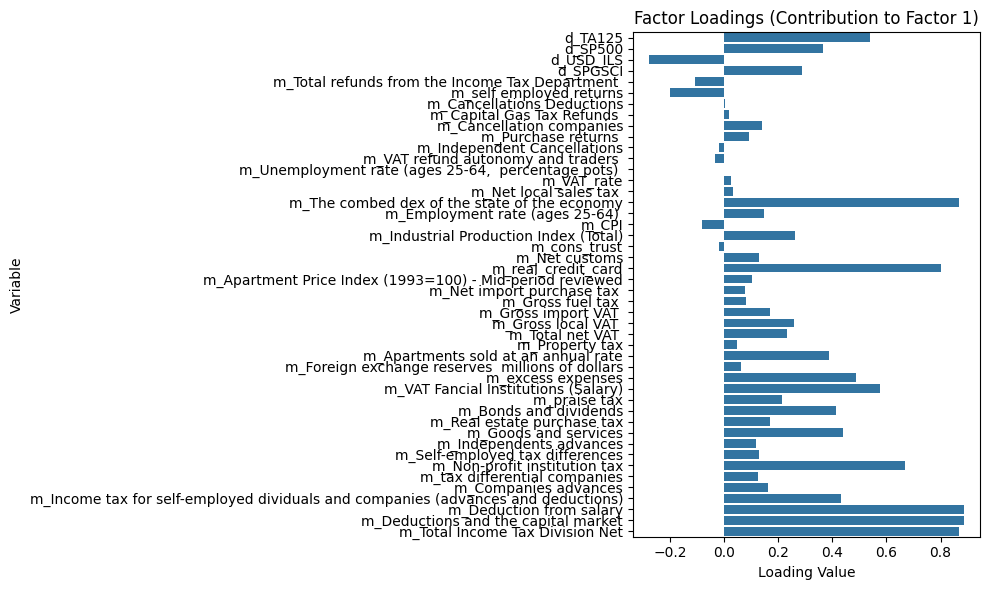

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

loadings = final_res.params.filter(like='loading')
loadings.index = [colname.replace('loading.f1.', '') for colname in loadings.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=loadings.values, y=loadings.index)
plt.title('Factor Loadings (Contribution to Factor 1)')
plt.xlabel('Loading Value')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


## N factors

### find optimal K

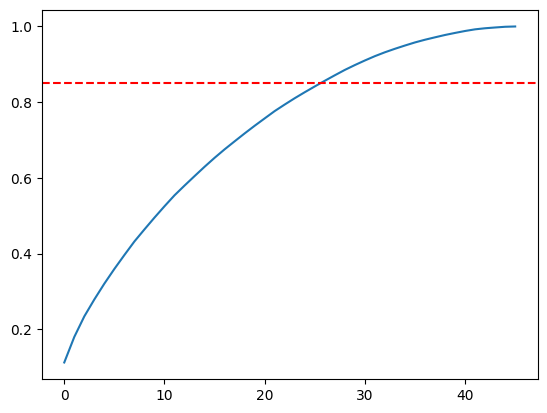

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(x_train_init)  # X_std = standardized monthly data
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.plot(cumulative)
plt.axhline(0.85, color='r', linestyle='--')

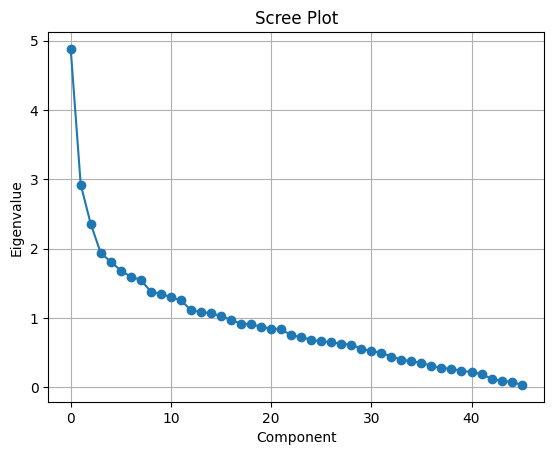

In [ ]:
pca = PCA()
pca.fit(x_train_init)

plt.plot(pca.explained_variance_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.grid()


### initialize

In [ ]:
k_factors = 4
factor_order = 1

mod_init = sm.tsa.DynamicFactor(
    x_train_init,
    k_factors=k_factors,
    factor_order=factor_order,
    error_cov_type="diagonal"
)

In [ ]:
init_powell = mod_init.fit(method="powell", maxiter=30, disp=True)

Optimization terminated successfully.
         Current function value: 64.830790
         Iterations: 20
         Function evaluations: 50489


In [ ]:
import pickle

with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/init_powell_fit_k_4.pkl", "wb") as f:
    pickle.dump(init_powell, f)


In [ ]:
init_res = mod_init.fit(
    start_params=init_powell.params,
    method="lbfgs",
    maxiter=90,
    full_output=True,
    disp=True,
    optim_score='approx',
    pgtol=1e-6,
    maxfun=5000
)


In [ ]:
with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/init_res_fit_k_4.pkl", "wb") as f:
    pickle.dump(init_res, f)

In [ ]:
print(f"Powell LLF: {init_powell.llf}")
print(f"LBFGS LLF:  {init_res.llf}")

Powell LLF: -640268.8856038008
LBFGS LLF:  -640260.3796869382


In [ ]:
print(init_res.aic, init_res.bic, init_res.hqic)


1281012.7593738765 1282783.433635091 1281612.4931837143


In [ ]:
import pickle

In [ ]:
with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/init_res_fit.pkl", "rb") as f:
    one_f_pre_train_mode = pickle.load(f)

In [ ]:
one_f_pre_train_mode.summary()

In [ ]:
print(type(one_f_pre_train_mode))

<class 'statsmodels.tsa.statespace.dynamic_factor.DynamicFactorResultsWrapper'>


In [ ]:
one_f_pre_train_mode.

In [ ]:
print(one_f_pre_train_mode.aic, one_f_pre_train_mode.bic, one_f_pre_train_mode.hqic)


1096819.8972473461 1097489.2984924393 1097046.6258827725


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/gdp_nowcasting_seminar/src')

In [ ]:
import dfm

### grid search

In [ ]:
import importlib
importlib.reload(dfm)

<module 'dfm' from '/content/drive/MyDrive/gdp_nowcasting_seminar/src/dfm.py'>

In [ ]:
results_table, models = dfm.fit_dfm_grid(
    X_train=x_train_init,
    k_factors_grid=[1, 2, 3],
    factor_order_grid=[1, 2],
    error_cov_grid=["diagonal"],
    method="powell",
    disp=True,
    save_dir="/content/drive/MyDrive/gdp_nowcasting_seminar/models"
)


Starting grid search...
--> Fitting model: k_factors=1, factor_order=1, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 60.670214
         Iterations: 11
         Function evaluations: 11525
    ✅ Fit successful. LLF=-599179.03, BIC=1199213.46
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/dfm_k1_p1_covdiagonal.pkl
--> Fitting model: k_factors=1, factor_order=2, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 60.625648
         Iterations: 12
         Function evaluations: 12701
    ✅ Fit successful. LLF=-598738.90, BIC=1198342.40
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/dfm_k1_p2_covdiagonal.pkl
--> Fitting model: k_factors=2, factor_order=1, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 63.761175
         Iterations: 8
         Function evaluations: 11994
    ✅ Fit successful. LLF=-

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3398: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 65.464600
         Iterations: 25
         Function evaluations: 51162
    ✅ Fit successful. LLF=-646528.39, BIC=1294831.97
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/dfm_k3_p1_covdiagonal.pkl
--> Fitting model: k_factors=3, factor_order=2, error_cov_type=diagonal


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3398: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 65.916864
         Iterations: 25
         Function evaluations: 55766
    ✅ Fit successful. LLF=-650994.95, BIC=1303847.87
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/dfm_k3_p2_covdiagonal.pkl
--> Fitting model: k_factors=4, factor_order=1, error_cov_type=diagonal


In [ ]:
import dfm

In [ ]:
results_table, models = dfm.fit_dfm_grid(
    X_train=x_train_init,
    k_factors_grid=[1],
    factor_order_grid=[3, 4, 5],
    error_cov_grid=["diagonal"],
    method="powell",
    disp=True,
    save_dir="/content/drive/MyDrive/gdp_nowcasting_seminar/models"
)


Starting grid search...
--> Fitting model: k_factors=1, factor_order=3, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 60.626165
         Iterations: 12
         Function evaluations: 12839
    ✅ Fit successful. LLF=-598744.01, BIC=1198361.81
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/dfm_k1_p3_covdiagonal.pkl
--> Fitting model: k_factors=1, factor_order=4, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 60.627967
         Iterations: 12
         Function evaluations: 12985
    ✅ Fit successful. LLF=-598761.80, BIC=1198406.59
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/dfm_k1_p4_covdiagonal.pkl
--> Fitting model: k_factors=1, factor_order=5, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 60.628093
         Iterations: 12
         Function evaluations: 13077
    ✅ Fit successful. LLF=

In [ ]:
results_table, models = dfm.fit_dfm_grid(
    X_train=x_train_init,
    k_factors_grid=[4],
    factor_order_grid=[3, 4],
    error_cov_grid=["diagonal"],
    method="powell",
    disp=True,
    save_dir="/content/drive/MyDrive/gdp_nowcasting_seminar/models"
)


NameError: name 'dfm' is not defined

### original data

In [ ]:
import statsmodels.api as sm

In [ ]:
mod_final = sm.tsa.DynamicFactor(
    x_train_z_score,
    k_factors=1,
    factor_order=2,
    error_cov_type="diagonal"
)

In [ ]:
final_res = mod_final.fit(
    start_params=best_model.params,
    method="powell",
    maxiter=200,
    disp=True
)

Optimization terminated successfully.
         Current function value: 4.586289
         Iterations: 5
         Function evaluations: 5464


In [ ]:
with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/mod_1_2_og_data.pkl", "wb") as f:
    pickle.dump(final_res, f)


### evaluations

In [ ]:
import pickle
file_path = "/content/drive/MyDrive/gdp_nowcasting_seminar/models/dfm_k1_p2_covdiagonal.pkl"
with open (file_path, "rb") as f:
  best_model = pickle.load(f)

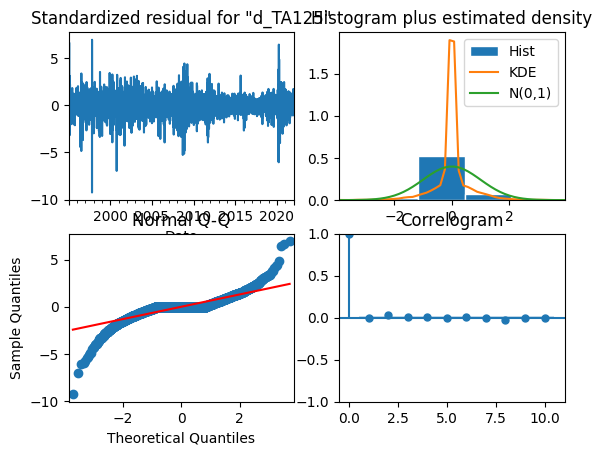

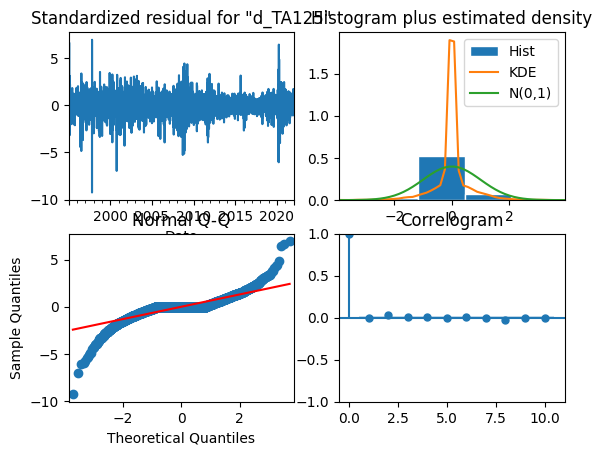

In [ ]:
final_res.plot_diagnostics()

In [ ]:
smoothed = final_res.smoothed_state
factor_series = smoothed[0, :]

In [ ]:
factor_df = pd.DataFrame({
    "factor": factor_series
}, index=best_model.data.row_labels)

eda.plot_time_series_altair(factor_df)

alt.Chart(...)

In [ ]:
factor_df.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df_k1_p2_covdiagonal.pkl')

## ragged edges

In [ ]:
max_factors = dfm.max_possible_factors(monthly_df_train_z_score)
print(f"Max factors you can safely request: {max_factors}")


Max factors you can safely request: 43


In [ ]:
k_factors = 1
factor_order = 1

mod_init = sm.tsa.DynamicFactor(
    monthly_df_train_z_score,
    k_factors=k_factors,
    factor_order=factor_order,
    error_cov_type="diagonal"
)

In [ ]:
init_powell = mod_init.fit(method="powell", maxiter=15, disp=True)

Optimization terminated successfully.
         Current function value: 51.536943
         Iterations: 13
         Function evaluations: 11943


In [ ]:
import importlib
importlib.reload(dfm)

<module 'dfm' from '/content/drive/MyDrive/gdp_nowcasting_seminar/src/dfm.py'>

### grid search

In [ ]:
results_table, models = dfm.fit_dfm_grid(
    X_train=monthly_df_train_z_score,
    k_factors_grid=[1, 2, 3, 4],
    factor_order_grid=[1, 2, 3],
    error_cov_grid=["diagonal"],
    method="powell",
    disp=True,
    save_dir="/content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly"
)


Starting grid search...
--> Fitting model: k_factors=1, factor_order=1, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 51.536943
         Iterations: 13
         Function evaluations: 11943
    ✅ Fit successful. LLF=-16749.51, BIC=34002.21
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k1_p1_covdiagonal.pkl
--> Fitting model: k_factors=1, factor_order=2, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 51.498849
         Iterations: 13
         Function evaluations: 12067
    ✅ Fit successful. LLF=-16737.13, BIC=33983.23
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k1_p2_covdiagonal.pkl
--> Fitting model: k_factors=1, factor_order=3, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 51.465668
         Iterations: 14
         Function evaluations

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3398: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 50.475519
         Iterations: 25
         Function evaluations: 35350
    ✅ Fit successful. LLF=-16404.54, BIC=33601.47
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k2_p2_covdiagonal.pkl
--> Fitting model: k_factors=2, factor_order=3, error_cov_type=diagonal


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3398: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 50.523967
         Iterations: 25
         Function evaluations: 36315
    ✅ Fit successful. LLF=-16420.29, BIC=33656.10
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k2_p3_covdiagonal.pkl
--> Fitting model: k_factors=3, factor_order=1, error_cov_type=diagonal


...

         Current function value: 50.847701
         Iterations: 25
         Function evaluations: 57285
    ✅ Fit successful. LLF=-16525.50, BIC=34387.07
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k4_p1_covdiagonal.pkl
--> Fitting model: k_factors=4, factor_order=2, error_cov_type=diagonal


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3398: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 50.941121
         Iterations: 25
         Function evaluations: 61595
    ✅ Fit successful. LLF=-16555.86, BIC=34540.33
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k4_p2_covdiagonal.pkl
--> Fitting model: k_factors=4, factor_order=3, error_cov_type=diagonal


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3398: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 51.090039
         Iterations: 25
         Function evaluations: 65551
    ✅ Fit successful. LLF=-16604.26, BIC=34729.67
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k4_p3_covdiagonal.pkl
✅ Grid search completed.


In [ ]:
results_table, models = dfm.fit_dfm_grid(
    X_train=monthly_df_train_z_score,
    k_factors_grid=[1, 2, 3, 4],
    factor_order_grid=[4, 5, 6],
    error_cov_grid=["diagonal"],
    method="powell",
    disp=True,
    save_dir="/content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly"
)


Starting grid search...
--> Fitting model: k_factors=1, factor_order=4, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 51.452311
         Iterations: 14
         Function evaluations: 13413
    ✅ Fit successful. LLF=-16722.00, BIC=33964.55
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k1_p4_covdiagonal.pkl
--> Fitting model: k_factors=1, factor_order=5, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 51.439852
         Iterations: 14
         Function evaluations: 13520
    ✅ Fit successful. LLF=-16717.95, BIC=33962.23
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k1_p5_covdiagonal.pkl
--> Fitting model: k_factors=1, factor_order=6, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 51.430256
         Iterations: 14
         Function evaluations

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3398: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 50.928530
         Iterations: 25
         Function evaluations: 37415
    ✅ Fit successful. LLF=-16551.77, BIC=33942.20
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k2_p4_covdiagonal.pkl
--> Fitting model: k_factors=2, factor_order=5, error_cov_type=diagonal


KeyboardInterrupt: 

In [ ]:
results_table, models = dfm.fit_dfm_grid(
    X_train=monthly_df_train_z_score,
    k_factors_grid=[2, 3, 4],
    factor_order_grid=[1, 2, 3, 4, 5],
    error_cov_grid=["diagonal"],
    method="powell",
    disp=True,
    save_dir="/content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly"
)


Starting grid search...
--> Fitting model: k_factors=2, factor_order=1, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 50.588354
         Iterations: 22
         Function evaluations: 30119
    ✅ Fit successful. LLF=-16441.22, BIC=33651.68
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k2_p1_covdiagonal.pkl
--> Fitting model: k_factors=2, factor_order=2, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 50.471311
         Iterations: 26
         Function evaluations: 36836
    ✅ Fit successful. LLF=-16403.18, BIC=33598.74
    📦 Saved model to: /content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k2_p2_covdiagonal.pkl
--> Fitting model: k_factors=2, factor_order=3, error_cov_type=diagonal
Optimization terminated successfully.
         Current function value: 50.519938
         Iterations: 26
         Function evaluations

#### results comparison

In [2]:
results = [
    # k=1
    (1, 1, 34002.21, -16749.51),
    (1, 2, 33983.23, -16737.13),
    (1, 3, 33967.44, -16726.34),
    (1, 4, 33964.55, -16722.00),
    (1, 5, 33962.23, -16717.95),
    (1, 6, 33961.78, -16714.83),
    # k=2
    (2, 1, 33651.68, -16441.22),
    (2, 2, 33598.74, -16403.18),
    (2, 3, 33653.48, -16418.98),
    (2, 4, 33598.62, -16379.98),
    (2, 5, 33691.91, -16415.06),
    # k=3
    (3, 1, 33667.82, -16310.48),
    (3, 2, 34291.29, -16596.18),
    (3, 3, 34108.43, -16478.73),
    (3, 4, 35047.65, -16922.31),
    (3, 5, 34965.99, -16855.45),
    # k=4
    (4, 1, 33395.97, -16029.95),
    (4, 2, 33338.89, -15955.14),
    (4, 3, 33950.31, -16214.58),
    (4, 4, 33608.60, -15997.46),
    (4, 5, 34782.16, -16537.97),
]


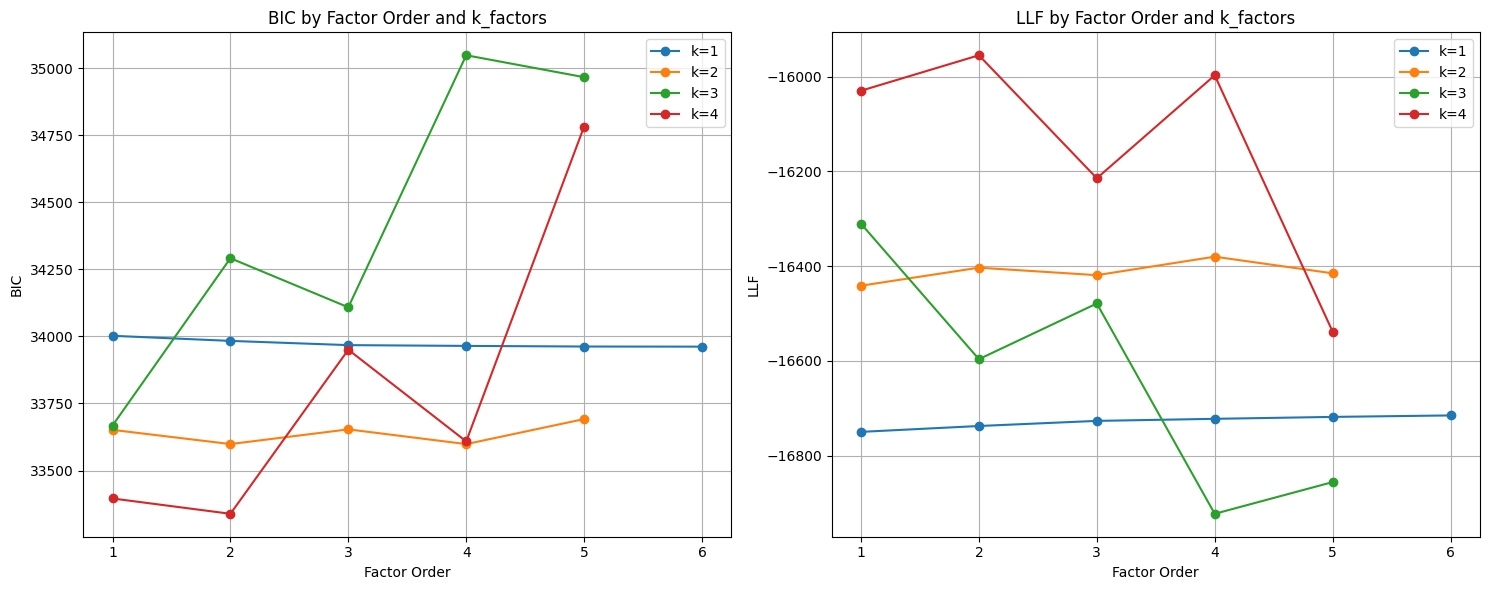

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.DataFrame(results, columns=['k_factors', 'factor_order', 'BIC', 'LLF'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot BIC
for k in results_df['k_factors'].unique():
    subset = results_df[results_df['k_factors'] == k]
    axes[0].plot(subset['factor_order'], subset['BIC'], marker='o', label=f'k={k}')
axes[0].set_title('BIC by Factor Order and k_factors')
axes[0].set_xlabel('Factor Order')
axes[0].set_ylabel('BIC')
axes[0].legend()
axes[0].grid(True)

# Plot LLF
for k in results_df['k_factors'].unique():
    subset = results_df[results_df['k_factors'] == k]
    axes[1].plot(subset['factor_order'], subset['LLF'], marker='o', label=f'k={k}')
axes[1].set_title('LLF by Factor Order and k_factors')
axes[1].set_xlabel('Factor Order')
axes[1].set_ylabel('LLF')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### evaluate best model

In [27]:
import pickle
file_path = "/content/drive/MyDrive/gdp_nowcasting_seminar/models/ragged_edge/monthly/dfm_k4_p2_covdiagonal.pkl"
with open (file_path, "rb") as f:
  best_model = pickle.load(f)

In [38]:
factors = pd.DataFrame(best_model.factors.smoothed.T, index=monthly_df_train_z_score.index.to_period('M').to_timestamp('M'), columns=[f"f{i+1}" for i in range(4)])

In [40]:
factors.describe()

,f1,f2,f3,f4
count,325.000000,325.000000,325.000000,325.000000
mean,0.005002,0.000395,-0.004162,0.001697
std,1.143363,0.750566,1.353804,1.114364
min,-6.580334,-3.694165,-4.224078,-7.302905
25%,-0.553686,-0.253588,-0.821203,-0.582708
50%,0.033085,-0.030714,0.046958,0.015935
75%,0.654019,0.234693,0.680968,0.677162
max,4.341285,4.702865,3.808678,4.213181


In [42]:
eda.plot_time_series_altair(factors)

alt.Chart(...)

In [43]:
factors.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df_k4_p2_covdiagonal.pkl')

#### filtered

In [41]:
import eda

In [39]:
factors = pd.DataFrame(
    best_model.factors.filtered.T,
    index=monthly_df_train_z_score.index,
    columns=[f"f{i+1}" for i in range(4)]
)

In [40]:
factors.describe()

,f1,f2,f3,f4
count,325.000000,325.000000,325.000000,325.000000
mean,0.007903,0.001720,-0.001090,0.002501
std,1.143680,0.749208,1.336554,1.111092
min,-6.582624,-3.694596,-4.118214,-7.312796
25%,-0.571047,-0.233986,-0.724948,-0.574870
50%,0.041258,-0.023309,0.014370,0.000000
75%,0.643670,0.229222,0.677758,0.644795
max,4.339247,4.732801,3.994621,4.242635


In [46]:
eda.plot_time_series_altair(factors)

alt.Chart(...)

In [47]:
factors.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df_k4_p2_covdiagonal.pkl')

### fit the test

In [64]:
test_res = best_model.apply(monthly_df_test_z_score)

In [65]:
Z = dfm.extract_factors(test_res, which="filtered").T
k = Z.shape[1]

test_factors = pd.DataFrame(
    Z,
    index=monthly_df_test_z_score.index,
    columns=[f"f{i+1}" for i in range(k)]
)

In [66]:
test_factors.describe()

,f1,f2,f3,f4
count,47.000000,47.000000,47.000000,47.000000
mean,0.014156,0.017824,-0.048821,0.062661
std,0.837946,0.792540,1.789347,1.216497
min,-1.568778,-1.617377,-3.966469,-2.768728
25%,-0.307402,-0.492861,-0.720009,-0.630838
50%,-0.099766,0.036439,-0.065691,0.136014
75%,0.380473,0.387506,0.929432,0.797453
max,3.146078,2.189626,3.839472,4.521670


In [67]:
test_factors.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 47 entries, 2021-06-01 to 2025-04-01
Freq: MS
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      47 non-null     float64
 1   f2      47 non-null     float64
 2   f3      47 non-null     float64
 3   f4      47 non-null     float64
dtypes: float64(4)
memory usage: 1.8 KB


In [68]:
eda.plot_time_series_altair(test_factors)

alt.Chart(...)

In [69]:
test_factors.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/test_factors_k4_p2_covdiagonal.pkl')